In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [7]:
df = pd.read_csv('data (1).csv')

In [9]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [12]:
# Drop artifact and non-feature columns if they exist in the dataframe
cols_to_drop = ['Unnamed: 32', 'id']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Re-check shape and null counts
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"Remaining Nulls: {df.isnull().sum().sum()}")

Cleaned Dataset Shape: (569, 31)
Remaining Nulls: 0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [14]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Diagnose & Display Outliers (Percentile Thresholds)

In [16]:
# Separate feature columns from target
numeric_features = [col for col in df.columns if col != 'diagnosis']

# Store detected outlier counts
outlier_summary = {}

# Detect values outside 1st and 99th percentiles
for col in numeric_features:
    p_lower = df[col].quantile(0.01)
    p_upper = df[col].quantile(0.99)

    outliers = df[(df[col] < p_lower) | (df[col] > p_upper)]
    if len(outliers) > 0:
        outlier_summary[col] = len(outliers)

# Display features with detected outliers
print("--- Detected Outliers per Feature (outside 1st-99th percentile) ---")
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=['Feature', 'Outlier Count'])
print(outlier_df)
print(f"\nTotal Outlier Data Points Across All Features: {sum(outlier_summary.values())}")

--- Detected Outliers per Feature (outside 1st-99th percentile) ---
                    Feature  Outlier Count
0               radius_mean             12
1              texture_mean             12
2            perimeter_mean             12
3                 area_mean             12
4           smoothness_mean             12
5          compactness_mean             12
6            concavity_mean              6
7       concave points_mean              6
8             symmetry_mean             12
9    fractal_dimension_mean             12
10                radius_se             12
11               texture_se             12
12             perimeter_se             12
13                  area_se             12
14            smoothness_se             12
15           compactness_se             12
16             concavity_se              6
17        concave points_se              6
18              symmetry_se             12
19     fractal_dimension_se             12
20             radius_worst  

In [18]:
post_check = 0

for col in numeric_features:
    # 1. Calculate original bounds ONCE
    p_lower = df[col].quantile(0.01)
    p_upper = df[col].quantile(0.99)

    # 2. Apply capping
    df[col] = np.clip(df[col], p_lower, p_upper)

    # 3. Verify against the exact SAME saved bounds
    remaining = len(df[(df[col] < p_lower) | (df[col] > p_upper)])
    post_check += remaining

print(f"Outlier Capping Complete. Outliers remaining outside 1st-99th bounds: {post_check}")

Outlier Capping Complete. Outliers remaining outside 1st-99th bounds: 0


In [21]:
# 1. Map string labels ('M', 'B') to numerical values (1, 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 2. Check Target Class Balance
print("--- Target Class Balance ---")
print(df['diagnosis'].value_counts(normalize=True).rename({1: 'Malignant (1)', 0: 'Benign (0)'}))

# 3. Calculate Top Feature Correlations with Target
print("\n--- Top 5 Features Most Correlated with Cancer Target ---")
correlations = df.corr()['diagnosis'].abs().sort_values(ascending=False)
print(correlations.iloc[1:6])

--- Target Class Balance ---
diagnosis
Benign (0)       0.627417
Malignant (1)    0.372583
Name: proportion, dtype: float64

--- Top 5 Features Most Correlated with Cancer Target ---
concave points_worst    0.794912
perimeter_worst         0.790318
concave points_mean     0.784934
radius_worst            0.782859
area_worst              0.750988
Name: diagnosis, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[numeric_features]
y = df['diagnosis']

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Fit scaler purely on training features to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train scaled shape: {X_train_scaled.shape}")
print(f"X_test scaled shape: {X_test_scaled.shape}")

X_train scaled shape: (455, 30)
X_test scaled shape: (114, 30)


In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Parameter grid testing Linear vs RBF and various C / Gamma levels
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

# Run 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Best Hyperparameters Found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.9758


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Extract best model
best_svc = grid_search.best_estimator_

# Predict on scaled test set
y_pred = best_svc.predict(X_test_scaled)

# Performance metrics
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Final Test Accuracy: 97.37%

--- Confusion Matrix ---
[[71  1]
 [ 2 40]]

--- Classification Report ---
              precision    recall  f1-score   support

   Malignant       0.97      0.99      0.98        72
      Benign       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [25]:
# 1. How many data points became Support Vectors?
print("Number of Support Vectors per class [Malignant, Benign]:", best_svc.n_support_)

# 2. View the actual coordinates of those Support Vectors
print("Support Vector Shape:", best_svc.support_vectors_.shape)

# 3. View the Dual Coefficients (weights multiplied by support vector labels)
print("Dual Coefficients Shape:", best_svc.dual_coef_.shape)

Number of Support Vectors per class [Malignant, Benign]: [53 57]
Support Vector Shape: (110, 30)
Dual Coefficients Shape: (1, 110)


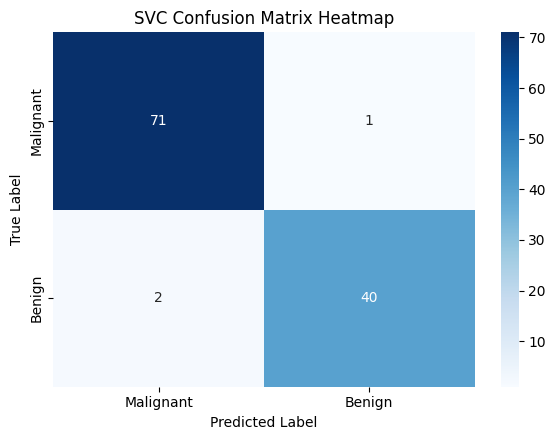

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])

plt.title('SVC Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

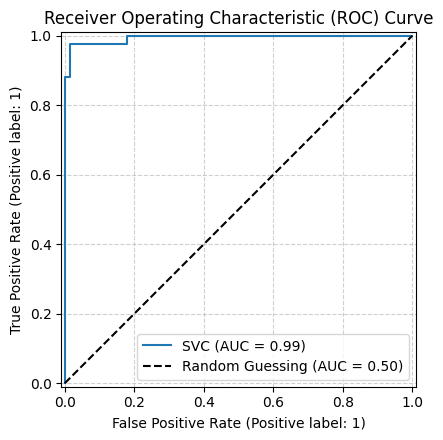

In [27]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC Curve directly from the trained SVC model
plt.figure(figsize=(6, 4.5))
RocCurveDisplay.from_estimator(best_svc, X_test_scaled, y_test, ax=plt.gca(), name='SVC')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

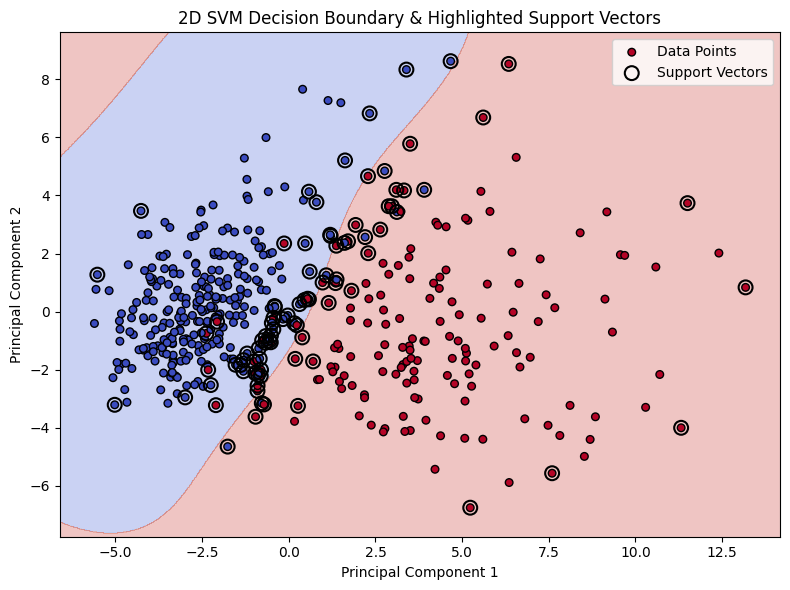

In [28]:
import numpy as np
from sklearn.decomposition import PCA

# 1. Reduce 30 features down to 2 components for visual plotting
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Train a 2D SVC model using your best parameters
svc_2d = SVC(kernel=best_svc.kernel, C=best_svc.C, gamma=best_svc.gamma)
svc_2d.fit(X_train_pca, y_train)

# 3. Create mesh grid coordinates
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict decision boundary regions
Z = svc_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot decision boundary, data points, and highlight support vectors
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=30, label='Data Points')

# Highlight Support Vectors
sv = svc_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

plt.title('2D SVM Decision Boundary & Highlighted Support Vectors')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()